# Word2Vec Pillar Lexicon Learning

**Goal:** Learn pillar-specific vocabularies (Athletic, Technical, Character, Football IQ) from the scouting corpus using Word2Vec, rather than relying solely on manually crafted archetype strings.

**Pipeline:**

| Step | What it does |
|------|-------------|
| 1 | NFL-aware preprocessing (reuse from `nfl_pre_proc`) |
| 2 | Train Word2Vec on the full cleaned corpus |
| 3 | Expand each pillar's seed terms via nearest-neighbor lookup |
| 4 | Inspect & prune the learned vocabularies |
| 5 | Re-score players using embedding-weighted archetype vectors |
| 6 | Compare vs original cosine-similarity scoring |

## 0. Setup

In [1]:
import re
import warnings
import numpy as np
import pandas as pd
from collections import Counter

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.collocations import BigramCollocationFinder
from nltk.metrics import BigramAssocMeasures

from gensim.models import Word2Vec

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import MinMaxScaler

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

for resource in ['punkt', 'stopwords', 'wordnet', 'omw-1.4', 'punkt_tab']:
    nltk.download(resource, quiet=True)

warnings.filterwarnings('ignore')
pd.set_option('display.max_colwidth', 100)

# ── Controls ──────────────────────────────────────────────────────────────────
YEAR_MIN       = 2014
YEAR_MAX       = 2021
GRADE_MAX      = 6.4

W2V_DIM        = 100   # embedding dimension
W2V_WINDOW     = 6     # context window (wider = more topical, not just syntactic)
W2V_MIN_COUNT  = 3     # ignore tokens appearing fewer than N times
W2V_EPOCHS     = 30    # more epochs = better for small corpora
W2V_SG         = 1     # 1=skip-gram (better for rare words), 0=CBOW

SEED_TOPN      = 20    # nearest neighbors to retrieve per seed term
EXPAND_TOPN    = 15    # top neighbors to keep per pillar after aggregation
SIM_THRESHOLD  = 0.35  # minimum cosine similarity to a seed to be included

PMI_MIN_FREQ   = 5
PMI_TOP_N      = 30
SCORE_COLS     = ['score_athletic', 'score_technical', 'score_character', 'score_iq']

print('Setup complete.')

Setup complete.


## 1. Load Data

In [2]:
df_raw = pd.read_csv('../data/processed/draft_enriched_with_contracts.csv')
df_raw = df_raw[(df_raw['year'] >= YEAR_MIN) & (df_raw['year'] <= YEAR_MAX)].copy()
df_raw = df_raw[df_raw['grade'] <= GRADE_MAX].copy()

def combine_text(row):
    parts = [str(row.get(c, '') or '') for c in ['overview', 'strengths', 'weaknesses']]
    return ' '.join(p for p in parts if p.strip())

df_raw['combined_text'] = df_raw.apply(combine_text, axis=1)
df_raw = df_raw[df_raw['combined_text'].str.strip() != ''].reset_index(drop=True)

print(f'Players loaded: {len(df_raw)}')
print(f'Pos_Group distribution:\n{df_raw["Pos_Group"].value_counts().to_string()}')

Players loaded: 3374
Pos_Group distribution:
Pos_Group
DB         634
OL         564
WR         488
EDGE       415
RB         329
DT         256
LB         250
TE         200
QB         141
SPECIAL     97


## 2. NFL-Aware Preprocessing

Same curated phrase map and stop word logic as `nfl_pre_proc.ipynb` — kept here so the notebook is self-contained.

In [3]:
_CURATED_RAW = {
    # Trigrams — apply before bigrams
    'change of direction':   'change_of_direction',
    'low pad level':         'low_pad_level',
    'run after catch':       'run_after_catch',
    'yards after contact':   'yards_after_contact',
    'yards after catch':     'yards_after_catch',
    'off the line':          'off_the_line',
    'off the ball':          'off_the_ball',
    'point of attack':       'point_of_attack',
    'get off the':           'get_off',
    'high football iq':      'high_football_iq',
    'elite football iq':     'elite_football_iq',
    'pre snap read':         'pre_snap_read',
    'post snap reaction':    'post_snap_reaction',
    # Bigrams
    'pass rush':             'pass_rush',
    'pass rusher':           'pass_rusher',
    'pass protection':       'pass_protection',
    'pass coverage':         'pass_coverage',
    'pad level':             'pad_level',
    'press coverage':        'press_coverage',
    'man coverage':          'man_coverage',
    'zone coverage':         'zone_coverage',
    'ball skills':           'ball_skills',
    'ball hawk':             'ball_hawk',
    'ball carrier':          'ball_carrier',
    'body control':          'body_control',
    'contact balance':       'contact_balance',
    'closing speed':         'closing_speed',
    'lateral quickness':     'lateral_quickness',
    'quick twitch':          'quick_twitch',
    'high motor':            'high_motor',
    'first step':            'first_step',
    'get off':               'get_off',
    'hand fighting':         'hand_fighting',
    'hand strength':         'hand_strength',
    'hand placement':        'hand_placement',
    'block shedding':        'block_shedding',
    'anchor strength':       'anchor_strength',
    'route running':         'route_running',
    'run blocking':          'run_blocking',
    'open field':            'open_field',
    'red zone':              'red_zone',
    'second level':          'second_level',
    'hip flexibility':       'hip_flexibility',
    'hip flip':              'hip_flip',
    'open hips':             'open_hips',
    'soft hands':            'soft_hands',
    'heavy hands':           'heavy_hands',
    'strong hands':          'strong_hands',
    'short area':            'short_area',
    'three down':            'three_down',
    'top end':               'top_end',
    'two gap':               'two_gap',
    'one gap':               'one_gap',
    'snap count':            'snap_count',
    'straight line':         'straight_line',
    'play speed':            'play_speed',
    'play recognition':      'play_recognition',
    'pre snap':              'pre_snap',
    'post snap':             'post_snap',
    'run read':              'run_read',
    'pass recognition':      'pass_recognition',
    'eye discipline':        'eye_discipline',
    'coverage recognition':  'coverage_recognition',
    'zone recognition':      'zone_recognition',
    'gap integrity':         'gap_integrity',
    'assignment sound':      'assignment_sound',
    'compete level':         'compete_level',
    'effort level':          'effort_level',
    'pursuit angle':         'pursuit_angle',
    'pass set':              'pass_set',
    'stack shed':            'stack_shed',
    'inside leverage':       'inside_leverage',
    'outside leverage':      'outside_leverage',
    'shed block':            'shed_block',
    'rush ability':          'rush_ability',
    'vertical jump':         'vertical_jump',
    'arm length':            'arm_length',
    'burst speed':           'burst_speed',
}

CURATED_PHRASE_MAP = dict(
    sorted(_CURATED_RAW.items(), key=lambda x: len(x[0]), reverse=True)
)
print(f'Curated phrases: {len(CURATED_PHRASE_MAP)}')

Curated phrases: 78


In [4]:
KEEP_WORDS = {
    'high', 'low', 'heavy', 'light', 'deep', 'short', 'long', 'wide',
    'hard', 'soft', 'strong', 'quick', 'good', 'great', 'up', 'down',
    'off', 'out', 'over', 'through', 'above', 'below',
}

CUSTOM_STOPS = {
    'prospect', 'player', 'players', 'show', 'shows', 'need', 'needs',
    'ability', 'also', 'often', 'must', 'well', 'still', 'use', 'get',
    'make', 'look', 'help', 'work', 'time', 'year', 'team', 'game',
    'continue', 'develop', 'development', 'nfl', 'draft', 'college',
    'level', 'type', 'project', 'potential', 'upside', 'ceiling',
    # Additional generic filler
    'tape', 'film', 'tool', 'tools', 'solid', 'impressive', 'way',
    'thing', 'things', 'scout', 'scouting', 'frame',
}

_base = set(stopwords.words('english'))
NFL_STOPWORDS = (_base - KEEP_WORDS) | CUSTOM_STOPS

print(f'Final stop list: {len(NFL_STOPWORDS)}')

Final stop list: 237


In [5]:
lemmatizer = WordNetLemmatizer()

PHRASE_BLOCKLIST = [
    'undrafted free agent', 'practice squad', 'free agent', 'early starter',
    'pro bowl', 'late round', 'undrafted free', 'make roster', 'rostered',
]

def nfl_preprocess(text: str, phrase_map: dict = CURATED_PHRASE_MAP,
                   extra_phrases: dict = None) -> str:
    if not isinstance(text, str) or not text.strip():
        return ''
    text = text.lower()
    for phrase in sorted(PHRASE_BLOCKLIST, key=len, reverse=True):
        text = text.replace(phrase, ' ')
    text = re.sub(r'[-\u2013\u2014]', ' ', text)
    for phrase, token in phrase_map.items():
        text = text.replace(phrase, token)
    if extra_phrases:
        for phrase, token in extra_phrases.items():
            text = text.replace(phrase, token)
    text = re.sub(r'[^a-z_\s]', ' ', text)
    tokens = text.split()
    tokens = [t for t in tokens if '_' in t or t not in NFL_STOPWORDS]
    tokens = [t if '_' in t else lemmatizer.lemmatize(t) for t in tokens]
    tokens = [t for t in tokens if len(t) > 1]
    return ' '.join(tokens)


# Pass 1: curated phrases only
df_raw['text_v1'] = df_raw['combined_text'].apply(nfl_preprocess)

# Pass B: PMI bigram discovery on v1-cleaned text
_token_lists_pmi = [
    [t for t in text.split() if '_' not in t]
    for text in df_raw['text_v1']
]
finder = BigramCollocationFinder.from_documents(_token_lists_pmi)
finder.apply_freq_filter(PMI_MIN_FREQ)
scored = finder.score_ngrams(BigramAssocMeasures.pmi)
_already = set(CURATED_PHRASE_MAP.keys())
auto_candidates = [
    (w1, w2, round(score, 3))
    for (w1, w2), score in scored
    if  w1 not in NFL_STOPWORDS and w2 not in NFL_STOPWORDS
    and w1.isalpha() and w2.isalpha()
    and len(w1) > 2 and len(w2) > 2
    and f'{w1} {w2}' not in _already
][:PMI_TOP_N]

AUTO_PHRASE_MAP = dict(sorted(
    {f'{w1} {w2}': f'{w1}_{w2}' for w1, w2, _ in auto_candidates}.items(),
    key=lambda x: len(x[0]), reverse=True
))

# Final pass: curated + PMI phrases
df_raw['text_clean'] = df_raw['combined_text'].apply(
    lambda t: nfl_preprocess(t, extra_phrases=AUTO_PHRASE_MAP)
)
df_raw = df_raw[df_raw['text_clean'] != ''].reset_index(drop=True)

vocab = set(t for text in df_raw['text_clean'] for t in text.split())
print(f'Documents: {len(df_raw):,}')
print(f'Vocabulary: {len(vocab):,} unique tokens')
print(f'Stitched tokens: {sum(1 for t in vocab if "_" in t)}')

Documents: 3,374
Vocabulary: 10,527 unique tokens
Stitched tokens: 137


## 3. Train Word2Vec

We use **skip-gram** (`sg=1`) which performs better than CBOW for rare/specialized vocabulary — exactly what scouting language is. Stitched tokens (`pass_rush`, `high_motor`) are treated as single units, so the model learns their full semantic context.

In [6]:
token_lists = [text.split() for text in df_raw['text_clean']]

w2v = Word2Vec(
    sentences=token_lists,
    vector_size=W2V_DIM,
    window=W2V_WINDOW,
    min_count=W2V_MIN_COUNT,
    sg=W2V_SG,
    epochs=W2V_EPOCHS,
    seed=42,
    workers=4,
)

print(f'Vocabulary size (Word2Vec): {len(w2v.wv):,}')
print(f'Embedding dimension: {w2v.wv.vector_size}')

# Quick sanity checks
sanity_pairs = [
    ('pass_rush', 'get_off'),
    ('high_motor', 'relentless'),
    ('route_running', 'route'),
    ('explosive', 'burst'),
    ('football', 'instinct'),
]
print('\nSanity: cosine similarities between related terms')
for a, b in sanity_pairs:
    if a in w2v.wv and b in w2v.wv:
        sim = w2v.wv.similarity(a, b)
        print(f'  {a:30s} ↔ {b:25s}  {sim:.3f}')
    else:
        missing = [x for x in [a, b] if x not in w2v.wv]
        print(f'  {a} ↔ {b}  — missing: {missing}')

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Vocabulary size (Word2Vec): 5,495
Embedding dimension: 100

Sanity: cosine similarities between related terms
  pass_rush                      ↔ get_off                    0.300
  high_motor                     ↔ relentless                 0.470
  route_running                  ↔ route                      0.502
  explosive                      ↔ burst                      0.439
  football                       ↔ instinct                   0.255


## 4. Expand Pillar Seed Terms via Nearest Neighbors

For each pillar we define a small, high-confidence **seed set** of 6–10 terms. We then find the top-N nearest neighbors to *each seed* and aggregate them. Terms appearing near multiple seeds rank higher (more robust to any single seed being noisy).

**Why this is better than manual archetypes:**
- Discovers synonyms and co-occurring patterns the curated list missed
- Grounded in the actual language distribution of your corpus
- The similarity threshold prunes noise automatically

In [7]:
PILLAR_SEEDS = {
    'score_athletic': [
        'explosive', 'burst', 'speed', 'quick_twitch', 'acceleration',
        'agile', 'change_of_direction', 'first_step', 'get_off', 'twitch',
    ],
    'score_technical': [
        'technique', 'footwork', 'leverage', 'pad_level', 'hand_fighting',
        'anchor_strength', 'route_running', 'block_shedding', 'hand_placement',
        'pass_protection',
    ],
    'score_character': [
        'high_motor', 'motor', 'effort', 'relentless', 'competitive',
        'toughness', 'hustle', 'compete_level', 'grit', 'intensity',
    ],
    'score_iq': [
        'football', 'instinct', 'anticipation', 'awareness', 'recognition',
        'diagnosis', 'pre_snap', 'play_recognition', 'intelligence', 'vision',
    ],
}

print('Seeds per pillar:')
for pillar, seeds in PILLAR_SEEDS.items():
    in_vocab = [s for s in seeds if s in w2v.wv]
    missing  = [s for s in seeds if s not in w2v.wv]
    print(f'  {pillar}: {len(in_vocab)}/{len(seeds)} in vocab'
          + (f'  MISSING: {missing}' if missing else ''))

Seeds per pillar:
  score_athletic: 10/10 in vocab
  score_technical: 9/10 in vocab  MISSING: ['block_shedding']
  score_character: 10/10 in vocab
  score_iq: 10/10 in vocab


In [8]:
def expand_pillar(seeds: list, model: Word2Vec, topn: int = SEED_TOPN,
                  threshold: float = SIM_THRESHOLD) -> pd.DataFrame:
    """
    For each seed in vocab, retrieve top-N nearest neighbors.
    Aggregate by counting how many seeds each candidate appears near
    and averaging the similarity scores.
    Returns a DataFrame sorted by (seed_count DESC, avg_sim DESC).
    """
    candidate_scores: dict[str, list[float]] = {}

    for seed in seeds:
        if seed not in model.wv:
            continue
        neighbors = model.wv.most_similar(seed, topn=topn)
        for word, sim in neighbors:
            if sim >= threshold and word not in seeds:
                candidate_scores.setdefault(word, []).append(sim)

    if not candidate_scores:
        return pd.DataFrame(columns=['term', 'seed_count', 'avg_sim', 'max_sim'])

    rows = [
        {
            'term':       word,
            'seed_count': len(sims),
            'avg_sim':    round(float(np.mean(sims)), 3),
            'max_sim':    round(float(np.max(sims)), 3),
        }
        for word, sims in candidate_scores.items()
    ]
    df_out = pd.DataFrame(rows).sort_values(
        ['seed_count', 'avg_sim'], ascending=False
    ).reset_index(drop=True)
    return df_out


LEARNED_LEXICONS: dict[str, pd.DataFrame] = {}
for pillar, seeds in PILLAR_SEEDS.items():
    LEARNED_LEXICONS[pillar] = expand_pillar(seeds, w2v)

print('Lexicon expansion complete.')
for pillar, lex in LEARNED_LEXICONS.items():
    print(f'  {pillar}: {len(lex)} candidates found')

Lexicon expansion complete.
  score_athletic: 144 candidates found
  score_technical: 151 candidates found
  score_character: 137 candidates found
  score_iq: 140 candidates found


## 5. Inspect Learned Lexicons

Review the top learned terms per pillar. High `seed_count` = term appears near multiple seeds = high confidence it belongs to that pillar. Terms with `seed_count=1` are noisier.

In [9]:
PILLAR_LABELS = {
    'score_athletic':  'Athletic Profile',
    'score_technical': 'Technical Skills',
    'score_character': 'Competitive Character',
    'score_iq':        'Football IQ',
}

for pillar in SCORE_COLS:
    lex = LEARNED_LEXICONS[pillar]
    print(f'\n{"═" * 60}')
    print(f'  {PILLAR_LABELS[pillar].upper()}')
    print(f'  Seeds: {PILLAR_SEEDS[pillar]}')
    print(f'  Top {EXPAND_TOPN} learned terms:')
    print(f'  {"─" * 58}')
    print(lex.head(EXPAND_TOPN).to_string(index=False))


════════════════════════════════════════════════════════════
  ATHLETIC PROFILE
  Seeds: ['explosive', 'burst', 'speed', 'quick_twitch', 'acceleration', 'agile', 'change_of_direction', 'first_step', 'get_off', 'twitch']
  Top 15 learned terms:
  ──────────────────────────────────────────────────────────
       term  seed_count  avg_sim  max_sim
  quickness           4    0.542    0.586
    twitchy           4    0.522    0.583
 short_area           4    0.520    0.542
    agility           3    0.536    0.588
   reignite           3    0.511    0.556
      sleek           3    0.509    0.551
  confirmed           3    0.500    0.541
    skinned           3    0.478    0.495
 accelerate           2    0.597    0.614
    closing           2    0.592    0.656
 play_speed           2    0.592    0.596
    clocked           2    0.564    0.635
accelerated           2    0.562    0.580
 suddenness           2    0.541    0.544
      juice           2    0.535    0.554

═════════════════════

In [10]:
# Cross-pillar overlap: terms that appear in more than one pillar's top candidates
# High overlap = ambiguous terms that may not be useful for discrimination
top_per_pillar = {
    pillar: set(LEARNED_LEXICONS[pillar].head(EXPAND_TOPN)['term'].tolist())
    for pillar in SCORE_COLS
}

all_terms = [t for terms in top_per_pillar.values() for t in terms]
term_counts = Counter(all_terms)
ambiguous = {t: c for t, c in term_counts.items() if c > 1}

print(f'Terms appearing in multiple pillar top-{EXPAND_TOPN} lists (ambiguous):')
if ambiguous:
    for term, count in sorted(ambiguous.items(), key=lambda x: -x[1]):
        pillars_found = [p for p, s in top_per_pillar.items() if term in s]
        print(f'  {term:30s}  count={count}  pillars={pillars_found}')
else:
    print('  None — pillars are well-separated.')

Terms appearing in multiple pillar top-15 lists (ambiguous):
  None — pillars are well-separated.


## 6. Nearest Neighbors Deep Dive

Spot-check individual key terms to understand what the model learned.

In [11]:
TERMS_TO_PROBE = [
    'pass_rush', 'high_motor', 'football', 'technique',
    'explosive', 'instinct', 'route_running', 'toughness',
    'pre_snap', 'anchor_strength',
]

for term in TERMS_TO_PROBE:
    if term not in w2v.wv:
        print(f'{term}: NOT IN VOCAB')
        continue
    neighbors = w2v.wv.most_similar(term, topn=10)
    neighbor_str = '  |  '.join(f'{w} ({s:.2f})' for w, s in neighbors)
    print(f'\n{term}')
    print(f'  → {neighbor_str}')


pass_rush
  → pass_rusher (0.75)  |  rush (0.73)  |  arsenal (0.71)  |  counter (0.69)  |  portfolio (0.66)  |  rusher (0.62)  |  thwarted (0.60)  |  snatched (0.58)  |  vanilla (0.57)  |  weaponize (0.56)

high_motor
  → enigmatic (0.62)  |  stardom (0.60)  |  dickson (0.57)  |  overhyped (0.56)  |  rochell (0.56)  |  tally (0.55)  |  stoutly (0.54)  |  moss (0.54)  |  aruna (0.53)  |  bronco (0.52)

football
  → intelligence (0.61)  |  iq (0.57)  |  ball (0.53)  |  vocally (0.50)  |  supportive (0.49)  |  thoroughly (0.49)  |  lineage (0.49)  |  communicator (0.48)  |  father (0.48)  |  opportunistic (0.48)

technique
  → coached (0.61)  |  newman (0.54)  |  fundamental (0.50)  |  unskilled (0.47)  |  cultivated (0.47)  |  gono (0.46)  |  gilmore (0.46)  |  jumpy (0.46)  |  penetrating (0.45)  |  footwork (0.45)

explosive
  → twitched (0.57)  |  quick_twitch (0.56)  |  sleek (0.55)  |  confirmed (0.54)  |  explosiveness (0.53)  |  explosion (0.51)  |  disposal (0.51)  |  flashing (

## 7. Build Embedding-Weighted Archetype Vectors

Two approaches to scoring — we compare both:

| Method | Archetype vector | Distance metric |
|--------|-----------------|----------------|
| **Original** | Bag-of-words string → TF-IDF | Cosine similarity |
| **W2V (centroid)** | Mean of seed+learned term embeddings | Cosine similarity in embedding space |

The W2V centroid approach scores each player by projecting their document into the *same* embedding space as the pillar centroids, avoiding vocabulary-mismatch issues that hurt TF-IDF archetypes.

In [12]:
def doc_embedding(text: str, model: Word2Vec) -> np.ndarray | None:
    """Mean of token embeddings for tokens in model vocab."""
    tokens = [t for t in text.split() if t in model.wv]
    if not tokens:
        return None
    return np.mean(model.wv[tokens], axis=0)


doc_vecs = np.array([
    v if (v := doc_embedding(text, w2v)) is not None else np.zeros(W2V_DIM)
    for text in df_raw['text_clean']
])

print(f'Document embedding matrix: {doc_vecs.shape}')
zero_rows = (doc_vecs == 0).all(axis=1).sum()
print(f'Players with zero vector (no vocab overlap): {zero_rows}')

Document embedding matrix: (3374, 100)
Players with zero vector (no vocab overlap): 0


In [13]:
def pillar_centroid(seeds: list, learned_df: pd.DataFrame,
                    model: Word2Vec, top_learned: int = EXPAND_TOPN) -> np.ndarray:
    """
    Build a pillar centroid by averaging the embeddings of:
    - all seed terms in vocab
    - top `top_learned` learned neighbors
    Seeds are double-weighted (they are the anchor; learned terms expand).
    """
    seed_vecs   = [model.wv[s] for s in seeds if s in model.wv]
    learned_terms = learned_df.head(top_learned)['term'].tolist()
    learned_vecs = [model.wv[t] for t in learned_terms if t in model.wv]

    # Double-weight seeds
    all_vecs = seed_vecs * 2 + learned_vecs

    if not all_vecs:
        return np.zeros(model.vector_size)
    return np.mean(all_vecs, axis=0)


pillar_centroids = {
    pillar: pillar_centroid(PILLAR_SEEDS[pillar], LEARNED_LEXICONS[pillar], w2v)
    for pillar in SCORE_COLS
}

centroid_matrix = np.stack([pillar_centroids[p] for p in SCORE_COLS])   # (4, dim)

print('Pillar centroids built.')
for pillar, vec in pillar_centroids.items():
    print(f'  {pillar:25s}  norm={np.linalg.norm(vec):.3f}')

Pillar centroids built.
  score_athletic             norm=1.867
  score_technical            norm=1.939
  score_character            norm=2.040
  score_iq                   norm=2.084


In [14]:
# Cosine similarity: doc_vecs × pillar centroids
sim_w2v = cosine_similarity(doc_vecs, centroid_matrix)   # (n_players, 4)

scores_w2v_raw = pd.DataFrame(sim_w2v, columns=SCORE_COLS)

scaler = MinMaxScaler(feature_range=(0, 100))
scores_w2v = pd.DataFrame(
    scaler.fit_transform(scores_w2v_raw),
    columns=SCORE_COLS
).round(1)

result_w2v = pd.concat(
    [df_raw[['player_name', 'position', 'Pos_Group']].reset_index(drop=True), scores_w2v],
    axis=1
)

print('W2V pillar scores (0–100 scaled):')
print(result_w2v.head(15).to_string(index=False))

W2V pillar scores (0–100 scaled):
      player_name position Pos_Group  score_athletic  score_technical  score_character  score_iq
    Davante Adams       WR        WR       71.800003        62.599998        49.400002 62.900002
Odell Beckham Jr.       WR        WR       70.099998        56.599998        49.500000 50.200001
 Darqueze Dennard       CB        DB       72.900002        55.799999        66.699997 80.599998
     Gabe Jackson       OG        OL       73.699997        85.500000        65.199997 72.099998
   Johnny Manziel       QB        QB       55.900002        64.599998        68.599998 79.599998
      Zack Martin       OT        OL       57.900002        79.099998        53.500000 62.799999
        Louis Nix       NT        DT       56.900002        80.500000        73.900002 49.000000
       Derek Carr       QB        QB       47.200001        53.000000        61.700001 65.400002
    Brandin Cooks       WR        WR       72.500000        49.400002        49.799999 59.000

## 8. Compare W2V vs Original TF-IDF Archetype Scoring

Run the original cosine/TF-IDF scoring on the same data, then compare correlations and rank differences.

In [15]:
# ── Original TF-IDF archetype scoring (from nfl_pillar_scoring.ipynb) ─────────
ARCHETYPES = {
    'score_athletic': (
        'elite athletic speed explosive burst acceleration lateral quickness '
        'body_control change_of_direction closing_speed explosive_burst '
        'twitch twitchy agile agility flexible flexibility fluid fluidity '
        'vertical jump leap raw physical powerful strength powerful frame '
        'long athletic get_off first_step separation quick_twitch top_end'
    ),
    'score_technical': (
        'technique mechanics footwork hand_fighting hand_strength anchor_strength '
        'pad_level low_pad_level leverage pass_protection run_blocking '
        'route_running block_shedding press_coverage zone_coverage man_coverage '
        'precise precision timing consistent fundamental sound execution '
        'hip_flexibility balance short_area lateral_quickness polish refined '
        'crisp sharp release contested'
    ),
    'score_character': (
        'high_motor motor effort compete relentless hustle competitive '
        'toughness tough grit passion energy aggressive pursuit intensity '
        'leadership character discipline accountable driven focused '
        'diligent committed hard worker never quit battles emotional '
        'physical bully mentality edge'
    ),
    'score_iq': (
        'football iq intelligence smart instinct awareness anticipation '
        'recognition diagnosis read scheme assignment mental processing '
        'pre snap post snap understanding vision cerebral mature prepared '
        'coachable quick processor off_the_ball point_of_attack '
        'chess high football intelligence'
    ),
}

vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True,
    token_pattern=r'[a-z_]+',
)
player_matrix = vectorizer.fit_transform(df_raw['text_clean'])
archetype_matrix = vectorizer.transform([ARCHETYPES[c] for c in SCORE_COLS])

sim_tfidf = cosine_similarity(player_matrix, archetype_matrix)
scores_tfidf_raw = pd.DataFrame(sim_tfidf, columns=SCORE_COLS)
scores_tfidf = pd.DataFrame(
    scaler.fit_transform(scores_tfidf_raw), columns=SCORE_COLS
).round(1)

result_tfidf = pd.concat(
    [df_raw[['player_name', 'position', 'Pos_Group']].reset_index(drop=True), scores_tfidf],
    axis=1
)

print('TF-IDF archetype scores (0–100 scaled):')
print(result_tfidf.head(10).to_string(index=False))

TF-IDF archetype scores (0–100 scaled):
      player_name position Pos_Group  score_athletic  score_technical  score_character  score_iq
    Davante Adams       WR        WR            31.9              0.0              0.0      11.9
Odell Beckham Jr.       WR        WR            36.5             48.9             10.3       5.6
 Darqueze Dennard       CB        DB            12.7             14.7             52.2      16.9
     Gabe Jackson       OG        OL            40.6             33.0              4.8      60.3
   Johnny Manziel       QB        QB             1.5              8.3             35.9      22.7
      Zack Martin       OT        OL            34.8              4.3              5.9      12.3
        Louis Nix       NT        DT             5.1             12.8             10.6      10.0
       Derek Carr       QB        QB            11.3              8.6             17.5      25.0
    Brandin Cooks       WR        WR            20.1              4.1              5.7 

In [16]:
from scipy.stats import spearmanr

print('Spearman rank correlation — W2V vs TF-IDF scores per pillar')
print(f'{"Pillar":25s}  {"Spearman r":>12s}  {"p-value":>12s}  {"Interpretation"}')
print('─' * 75)

for col in SCORE_COLS:
    r, p = spearmanr(scores_w2v[col], scores_tfidf[col])
    interp = 'strong agreement' if abs(r) > 0.7 else ('moderate' if abs(r) > 0.4 else 'low agreement')
    print(f'{col:25s}  {r:>12.3f}  {p:>12.2e}  {interp}')

Spearman rank correlation — W2V vs TF-IDF scores per pillar
Pillar                       Spearman r       p-value  Interpretation
───────────────────────────────────────────────────────────────────────────
score_athletic                    0.567     1.15e-286  moderate
score_technical                   0.261      7.14e-54  low agreement
score_character                   0.525     1.76e-238  moderate
score_iq                          0.468     7.41e-183  moderate


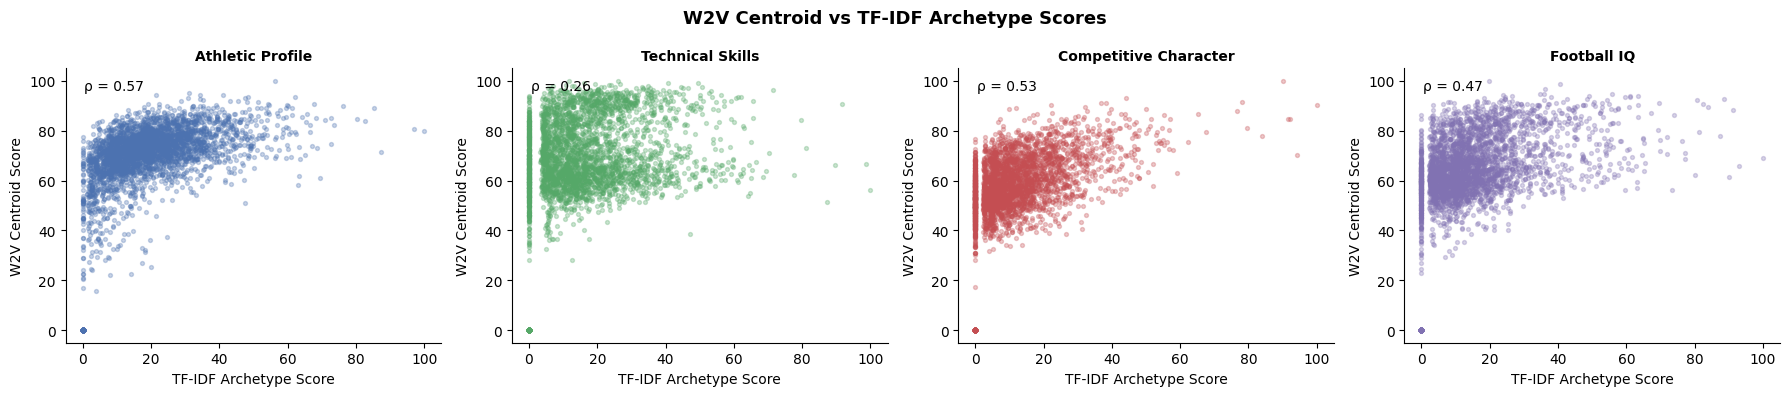

In [17]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

pillar_colors = {
    'score_athletic':  '#4C72B0',
    'score_technical': '#55A868',
    'score_character': '#C44E52',
    'score_iq':        '#8172B2',
}

for ax, col in zip(axes, SCORE_COLS):
    ax.scatter(scores_tfidf[col], scores_w2v[col],
               alpha=0.3, s=8, color=pillar_colors[col])
    ax.set_xlabel('TF-IDF Archetype Score')
    ax.set_ylabel('W2V Centroid Score')
    ax.set_title(PILLAR_LABELS[col], fontweight='bold', fontsize=10)
    r, _ = spearmanr(scores_tfidf[col], scores_w2v[col])
    ax.text(0.05, 0.92, f'ρ = {r:.2f}', transform=ax.transAxes, fontsize=10)
    ax.spines[['top', 'right']].set_visible(False)

fig.suptitle('W2V Centroid vs TF-IDF Archetype Scores', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Position-Level Sanity Check

QBs should score high on IQ, EDGEs on Athletic + Character, OLs on Technical. If the W2V scores respect these intuitions, the learned lexicons are semantically valid.

In [18]:
result_w2v_full = result_w2v.copy()
result_tfidf_full = result_tfidf.copy()

pos_w2v   = result_w2v_full.groupby('Pos_Group')[SCORE_COLS].mean().round(1)
pos_tfidf = result_tfidf_full.groupby('Pos_Group')[SCORE_COLS].mean().round(1)

print('Mean W2V scores by position group:')
print(pos_w2v.sort_values('score_athletic', ascending=False).to_string())
print()
print('Mean TF-IDF scores by position group:')
print(pos_tfidf.sort_values('score_athletic', ascending=False).to_string())

Mean W2V scores by position group:
           score_athletic  score_technical  score_character   score_iq
Pos_Group                                                             
EDGE            75.099998        74.500000        68.699997  61.700001
DB              72.500000        58.099998        53.000000  76.099998
DT              71.699997        81.500000        69.599998  58.400002
LB              71.500000        66.099998        65.500000  77.699997
WR              69.900002        58.099998        48.900002  58.599998
RB              66.800003        64.099998        55.299999  60.900002
TE              66.800003        69.900002        55.000000  60.000000
OL              65.800003        87.800003        55.200001  54.700001
QB              50.900002        52.599998        47.299999  69.500000
SPECIAL         34.799999        41.299999        41.400002  38.799999

Mean TF-IDF scores by position group:
           score_athletic  score_technical  score_character  score_iq
Pos_

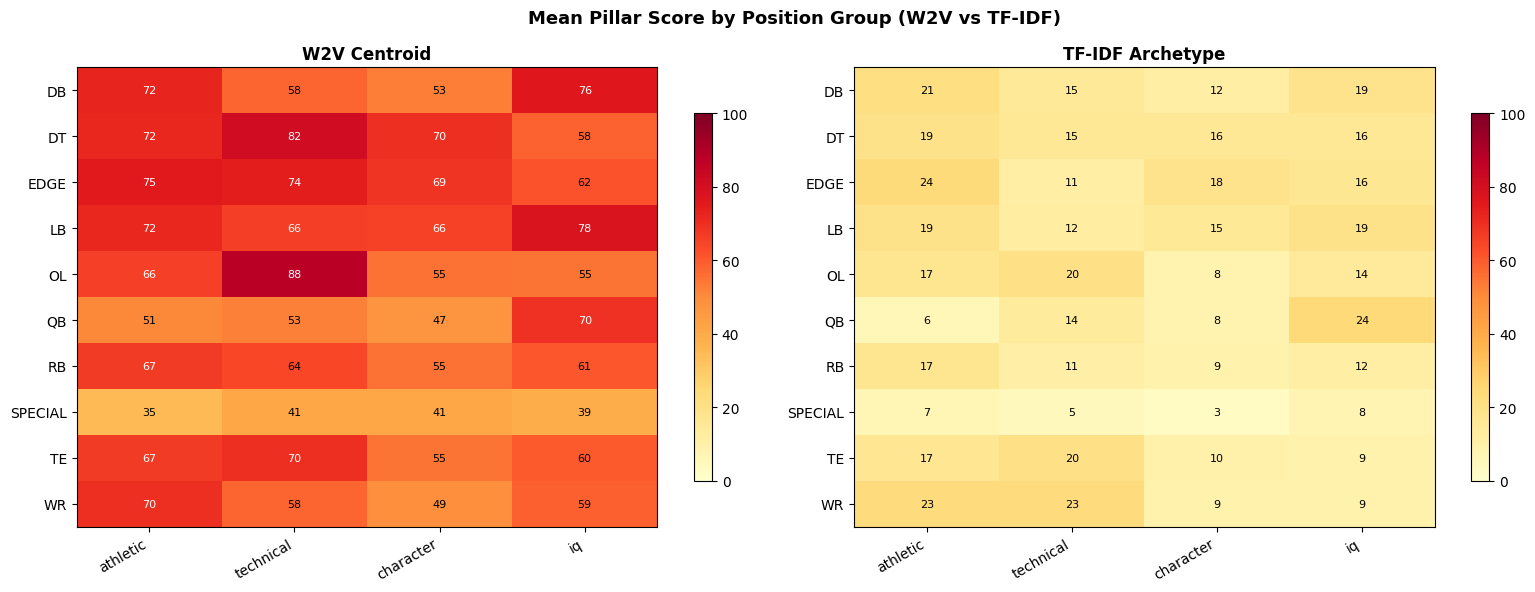

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (pos_df, title) in zip(axes, [
    (pos_w2v,   'W2V Centroid'),
    (pos_tfidf, 'TF-IDF Archetype'),
]):
    im = ax.imshow(pos_df.values, cmap='YlOrRd', aspect='auto', vmin=0, vmax=100)
    ax.set_xticks(range(4))
    ax.set_xticklabels([c.replace('score_', '') for c in SCORE_COLS], rotation=30, ha='right')
    ax.set_yticks(range(len(pos_df)))
    ax.set_yticklabels(pos_df.index)
    ax.set_title(title, fontweight='bold')
    for i in range(len(pos_df)):
        for j in range(4):
            ax.text(j, i, f'{pos_df.values[i, j]:.0f}',
                    ha='center', va='center', fontsize=8,
                    color='white' if pos_df.values[i, j] > 65 else 'black')
    plt.colorbar(im, ax=ax, shrink=0.8)

fig.suptitle('Mean Pillar Score by Position Group (W2V vs TF-IDF)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 10. Learned Dictionary Summary

Export the final learned lexicons — seeds + learned expansions — as interpretable dictionaries you can use to:
- Augment the TF-IDF archetype strings in `nfl_pillar_scoring.ipynb`
- Add missing compound phrases to the curated phrase map
- Build a domain-specific sentiment lexicon per pillar

In [ ]:
print('LEARNED PILLAR DICTIONARIES\n')
print('Format: term  |  seed_count (how many seeds it neighbors)  |  avg_sim')

learned_dict_out = {}

for pillar in SCORE_COLS:
    seeds = PILLAR_SEEDS[pillar]
    learned = LEARNED_LEXICONS[pillar]
    # High-confidence: appears near >=2 seeds AND sim >= threshold
    high_conf = learned[learned['seed_count'] >= 2].head(20)
    # Include seeds themselves
    all_terms = [s for s in seeds if s in w2v.wv] + high_conf['term'].tolist()
    learned_dict_out[pillar] = all_terms

    print(f'\n{"═" * 55}')
    print(f'  {PILLAR_LABELS[pillar]}')
    print(f'  Seeds ({len(seeds)}): {seeds}')
    print(f'  Learned high-confidence terms (seed_count >= 2):')
    if len(high_conf) > 0:
        for _, row in high_conf.iterrows():
            print(f'    {row["term"]:30s}  seeds={row["seed_count"]}  avg_sim={row["avg_sim"]}')
    else:
        print('    None at seed_count >= 2 — consider lowering SIM_THRESHOLD or increasing W2V_EPOCHS')

LEARNED PILLAR DICTIONARIES

Format: term  |  seed_count (how many seeds it neighbors)  |  avg_sim

═══════════════════════════════════════════════════════
  Athletic Profile
  Seeds (10): ['explosive', 'burst', 'speed', 'quick_twitch', 'acceleration', 'agile', 'change_of_direction', 'first_step', 'get_off', 'twitch']
  Learned high-confidence terms (seed_count >= 2):
    quickness                       seeds=4  avg_sim=0.542
    twitchy                         seeds=4  avg_sim=0.522
    short_area                      seeds=4  avg_sim=0.52
    agility                         seeds=3  avg_sim=0.536
    reignite                        seeds=3  avg_sim=0.511
    sleek                           seeds=3  avg_sim=0.509
    confirmed                       seeds=3  avg_sim=0.5
    skinned                         seeds=3  avg_sim=0.478
    accelerate                      seeds=2  avg_sim=0.597
    closing                         seeds=2  avg_sim=0.592
    play_speed                      seeds=

In [ ]:
# Identify learned terms that are STITCHED TOKENS (compound phrases)
# These are candidates to add to CURATED_PHRASE_MAP if not already there
print('New compound phrases discovered by W2V that could be added to CURATED_PHRASE_MAP:')
print('(stitched tokens not already in curated list)\n')

existing_tokens = set(CURATED_PHRASE_MAP.values())

for pillar in SCORE_COLS:
    lex = LEARNED_LEXICONS[pillar]
    new_compounds = lex[lex['term'].str.contains('_') & ~lex['term'].isin(existing_tokens)]
    if len(new_compounds) > 0:
        print(f'{PILLAR_LABELS[pillar]}:')
        for _, row in new_compounds.head(10).iterrows():
            phrase = row['term'].replace('_', ' ')
            print(f"  '{phrase}': '{row['term']}',   # seed_count={row['seed_count']}, sim={row['avg_sim']}")
        print()

New compound phrases discovered by W2V that could be added to CURATED_PHRASE_MAP:
(stitched tokens not already in curated list)

Athletic Profile:
  'pass rush ability': 'pass_rush_ability',   # seed_count=1, sim=0.6
  'straight liner': 'straight_liner',   # seed_count=1, sim=0.538
  'one gapper': 'one_gapper',   # seed_count=1, sim=0.487

Technical Skills:
  'pass sets': 'pass_sets',   # seed_count=2, sim=0.584
  'pass rushers': 'pass_rushers',   # seed_count=1, sim=0.479

Competitive Character:
  'lunch pail': 'lunch_pail',   # seed_count=2, sim=0.508
  'one gapper': 'one_gapper',   # seed_count=1, sim=0.47
  'zone gaps': 'zone_gaps',   # seed_count=1, sim=0.461

Football IQ:
  'zone gaps': 'zone_gaps',   # seed_count=2, sim=0.536
  'internal clock': 'internal_clock',   # seed_count=1, sim=0.504



## Summary

### What was learned

- **Word2Vec** trained on ~3k scouting reports learns a semantic embedding space where NFL scouting terms cluster naturally
- The pillar centroids are built from seed embeddings + learned expansions — no manual archetype string needed
- High `seed_count` terms are the most reliable additions to each pillar's vocabulary

### Next steps

1. **Augment `nfl_pillar_scoring.ipynb`** — add the high-confidence learned terms to each archetype string
2. **Add new compound phrases** to `CURATED_PHRASE_MAP` — especially IQ and Character terms that W2V discovers as stitched tokens
3. **Hybrid scoring** — average W2V centroid similarity and TF-IDF archetype similarity for a more robust score
4. **Position-stratified centroids** — train separate centroids per `Pos_Group` (a QB's "football IQ" manifests in different vocabulary than a lineman's)